# Import Libraries

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from src.preprocessing import load_data, split_data
from src.evaluation import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    plot_roc_curve,
)

# Load Dataset

In [2]:
X, y = load_data()

X_train, X_test, y_train, y_test = split_data(X, y)

# Load Trained Pipeline


In [4]:
model = joblib.load("../models/best_pipeline.pkl")

# Performance Metrics

In [5]:
metrics = evaluate_model(model, X_test, y_test)

pd.DataFrame(metrics, index=["Score"]).T

,Score
Accuracy,0.893542
Precision,0.892710
Recall,0.809949
F1 Score,0.849318
ROC AUC,0.958527


# Classification Report

In [6]:
print_classification_report(
    model,
    X_test,
    y_test,
)

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     15033
           1       0.89      0.81      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.88      0.88     23878
weighted avg       0.89      0.89      0.89     23878



# Confusion Matrix

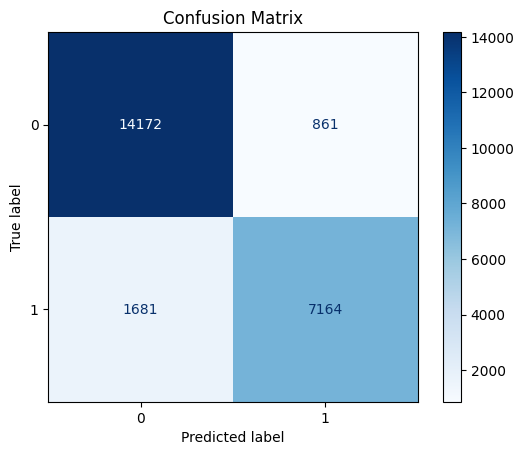

In [8]:
plot_confusion_matrix(
    model,
    X_test,
    y_test,
    save_path="../results/confusion_matrix.png",
)

# ROC Curve

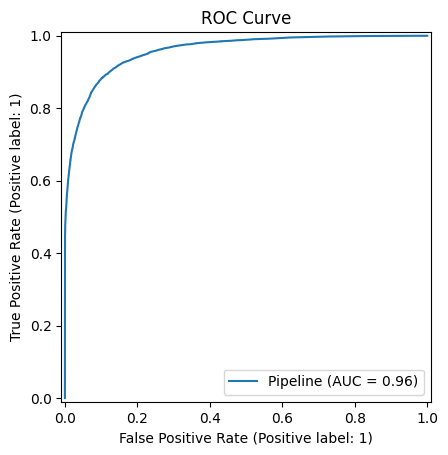

In [9]:
plot_roc_curve(
    model,
    X_test,
    y_test,
    save_path="../results/roc_curve.png",
)

# Sample Predictions


In [11]:
sample = X_test.iloc[:10]

pred = model.predict(sample)
prob = model.predict_proba(sample)

pd.DataFrame({
    "Prediction": pred,
    "Probability": prob[:,1]
})

,Prediction,Probability
0,0,0.109447
1,0,0.030000
2,1,0.775000
3,0,0.090000
4,0,0.000000
5,1,1.000000
6,1,1.000000
7,1,0.780000
8,0,0.145000
9,0,0.000000


# Feature Importance


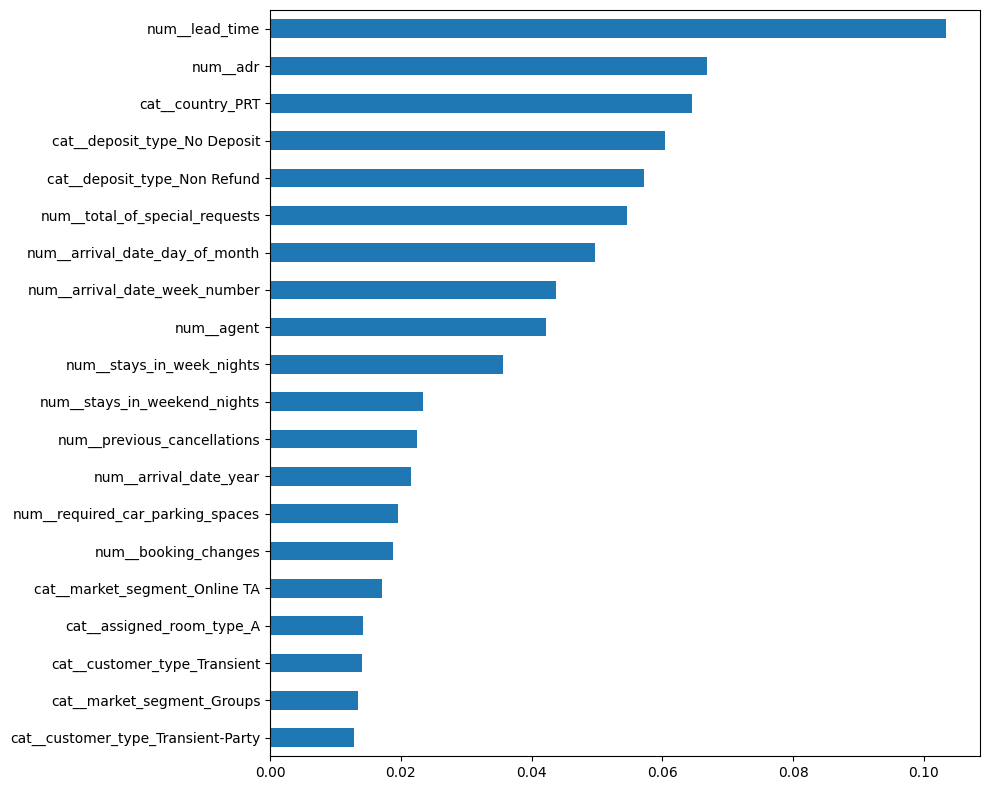

In [12]:
preprocessor = model.named_steps["preprocessor"]
rf = model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
)

importance.sort_values().tail(20).plot.barh(figsize=(10, 8))
plt.tight_layout()
plt.show()